<a href="https://colab.research.google.com/github/JAHANTRISHA/Research-with-Python/blob/main/Perceptron/Assignment_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Task: Credit Card Fraud Detection
Dataset: Kaggle Credit Card Fraud

Your Tasks:
1. **Load and explore dataset**
    - Check class imbalance (fraud cases are very rare)
2. **Prepare data**
    - Handle missing data
    - Standardize features

3. **Train two models**
    - One with Batch GD
    - One with Stochastic GD

4. **Compare:**
    - Which converges faster?
    - Which has better accuracy?
    - Precision, Recall, F1-Score?

In [1]:
# HOMEWORK
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load and explore dataset

In [3]:
# Step 1: Load data
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('/content/drive/MyDrive/skillMorph/Class12/creditcard.csv')
print(df.head())
print(df['Class'].value_counts())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

## Missing value exist or not

In [4]:
# Basic exploration
print("Dataset Shape:", df.shape)

print("\nDataset Info:")
print(df.info())

print("\nBasic Statistics:")
print(df.describe())

print("\nCheck for missing values:")
print(df.isnull().sum())

print("\nTarget variable distribution:")
print(df['Class'].value_counts())

Dataset Shape: (284807, 31)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20  

## Prepare data

In [5]:
# Step 2: Prepare data
X = df.drop('Class', axis=1).values
y = df['Class'].values


In [6]:
!pip install imbalanced-learn

In [7]:
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Before balancing
print("Before:", Counter(y))

# Step 3: Handle imbalance
# Create the undersampler
rus = RandomUnderSampler(random_state=42)

# Apply undersampling
X_balanced, y_balanced = rus.fit_resample(X, y)

# After balancing
print("After:", Counter(y_balanced))


Before: Counter({np.int64(0): 284315, np.int64(1): 492})
After: Counter({np.int64(0): 492, np.int64(1): 492})


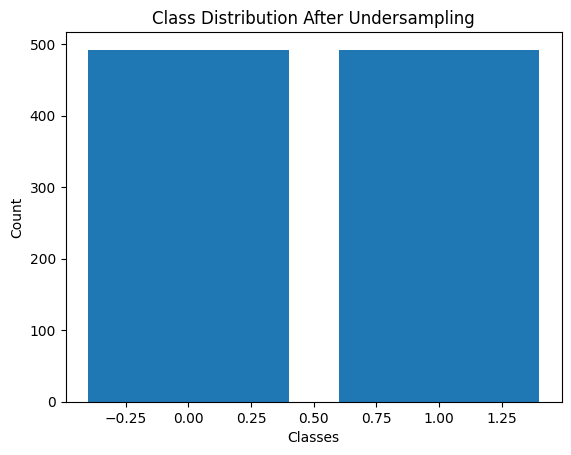

In [15]:
import matplotlib.pyplot as plt
from collections import Counter

counts = Counter(y_balanced)
plt.bar(counts.keys(), counts.values())
plt.xlabel("Classes")
plt.ylabel("Count")
plt.title("Class Distribution After Undersampling")
plt.show()


In [ ]:
# Step 3: Handle imbalance
#rus = RandomUnderSampler(random_state=42)
#X_balanced, y_balanced = rus.fit_resample(X, y)

In [8]:
# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,    # 20% for test
    random_state=20   # Same result every time
)

print(f"\nWe will train with: {len(X_train)} data")
print(f"We will test with: {len(X_test)} data")


We will train with: 787 data
We will test with: 197 data


In [9]:
# Standardize (important!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nData ready!")


Data ready!


In [ ]:
## Step 4: Train both models and compare!

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Two most important activation functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)


In [12]:
class Perceptron:
    def __init__(self, lr=0.01, epochs=100, mode='batch'):
        self.lr = lr
        self.epochs = epochs
        self.mode = mode
        self.w = None
        self.b = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros(d)
        self.b = 0

        for epoch in range(self.epochs):
            if self.mode == 'batch':
                z = X.dot(self.w) + self.b
                pred = self.sigmoid(z)
                self.w -= self.lr * X.T.dot(pred - y) / n
                self.b -= self.lr * (pred - y).mean()
            else:
                for i in range(n):
                    z = X[i].dot(self.w) + self.b
                    pred = self.sigmoid(z)
                    self.w -= self.lr * (pred - y[i]) * X[i]
                    self.b -= self.lr * (pred - y[i])

    def predict(self, X):
        return (self.sigmoid(X.dot(self.w) + self.b) >= 0.5).astype(int)

print("Perceptron class created!")

Perceptron class created!


## Train two models

In [36]:
# Train with Batch GD
print("-"*50)
print("Training with BATCH Gradient Descent")
print("-"*50)

model_batch = Perceptron(lr=0.1, epochs=200, mode='batch')
model_batch.fit(X_train, y_train)

y_pred_batch = model_batch.predict(X_test)
acc_batch = accuracy_score(y_test, y_pred_batch)
prec_batch = precision_score(y_test, y_pred_batch)
rec_batch = recall_score(y_test, y_pred_batch)
f1_batch = f1_score(y_test, y_pred_batch)

print(f"\nTest Accuracy:  {acc_batch*100:.2f}%")
print(f"Precision:      {prec_batch*100:.2f}%")
print(f"Recall:         {rec_batch*100:.2f}%")
print(f"F1-Score:       {f1_batch*100:.2f}%")
print(f"\nCorrect: {sum(y_pred_batch == y_test)}/{len(y_test)}")

--------------------------------------------------
Training with BATCH Gradient Descent
--------------------------------------------------

Test Accuracy:  90.86%
Precision:      100.00%
Recall:         81.25%
F1-Score:       89.66%

Correct: 179/197


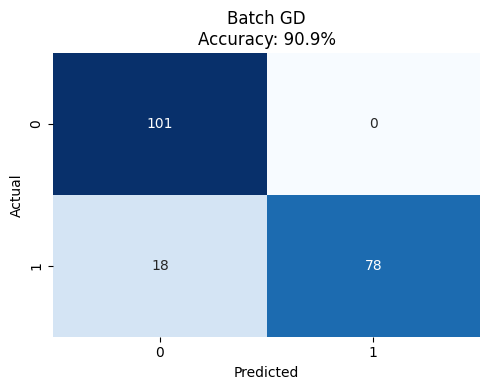

In [37]:
fig, axes = plt.subplots(1, 1, figsize=(5, 4))

# Confusion Matrix - Batch
cm_batch = confusion_matrix(y_test, y_pred_batch)
sns.heatmap(cm_batch, annot=True, fmt='d', cmap='Blues', ax=axes, cbar=False)
axes.set_title(f'Batch GD\nAccuracy: {acc_batch*100:.1f}%', fontsize=12)
axes.set_xlabel('Predicted')
axes.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [38]:
# Train with Stochastic GD
print("-"*50)
print("Training with STOCHASTIC Gradient Descent")
print("-"*50)

model_sgd = Perceptron(lr=0.1, epochs=200, mode='stochastic')
model_sgd.fit(X_train, y_train)

y_pred_sgd = model_sgd.predict(X_test)
acc_sgd = accuracy_score(y_test, y_pred_sgd)
prec_sgd = precision_score(y_test, y_pred_sgd)
rec_sgd = recall_score(y_test, y_pred_sgd)
f1_sgd = f1_score(y_test, y_pred_sgd)

print(f"\nTest Accuracy:  {acc_sgd*100:.2f}%")
print(f"Precision:      {prec_sgd*100:.2f}%")
print(f"Recall:         {rec_sgd*100:.2f}%")
print(f"F1-Score:       {f1_sgd*100:.2f}%")
print(f"\nCorrect: {sum(y_pred_sgd == y_test)}/{len(y_test)} ")

--------------------------------------------------
Training with STOCHASTIC Gradient Descent
--------------------------------------------------

Test Accuracy:  93.91%
Precision:      100.00%
Recall:         87.50%
F1-Score:       93.33%

Correct: 185/197


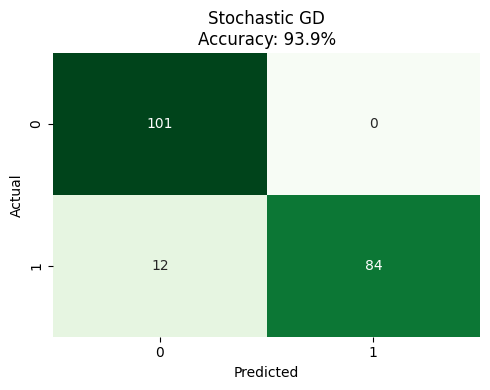

In [34]:
# Confusion Matrix - Stochastic
fig, axes = plt.subplots(1, 1, figsize=(5, 4))

cm_sgd = confusion_matrix(y_test, y_pred_sgd)
sns.heatmap(cm_sgd, annot=True, fmt='d', cmap='Greens', ax=axes, cbar=False)
axes.set_title(f'Stochastic GD\nAccuracy: {acc_sgd*100:.1f}%', fontsize=12)
axes.set_xlabel('Predicted')
axes.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Compare

In [49]:
# Print comparison table
print("\n" + "-"*60)
print("COMPARISON: Batch GD vs Stochastic GD")
print("-"*60)
print(f"{'Metric':<17} | {'Batch GD':<12} | {'Stochastic GD':<16}")
print("-"*60)
print(f"{'Accuracy':<17}| {acc_batch*100:>12.2f}% | {acc_sgd*100:>16.2f}%")
print(f"{'Precision':<17}| {prec_batch*100:>12.2f}% | {prec_sgd*100:>16.2f}%")
print(f"{'Recall':<17}| {rec_batch*100:>12.2f}% | {rec_sgd*100:>16.2f}%")
print(f"{'F1-Score':<17}| {f1_batch*100:>12.2f}% |{f1_sgd*100:>16.2f}%")
print("-"*60)
print("Comparison is complete!")
print("-"*60)


------------------------------------------------------------
COMPARISON: Batch GD vs Stochastic GD
------------------------------------------------------------
Metric            | Batch GD     | Stochastic GD   
------------------------------------------------------------
Accuracy         |        90.86% |            93.91%
Precision        |       100.00% |           100.00%
Recall           |        81.25% |            87.50%
F1-Score         |        89.66% |           93.33%
------------------------------------------------------------
Comparison is complete!
------------------------------------------------------------


In [40]:
print("Work with Perception is completed!")

Work with Perception is completed!
